**# Definitive Formula 1 Data Mining (14-Dataset Architecture)**


## Phase 1: Environment Setup
**Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Set a clean, modern aesthetic for standalone plots
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#0B0E14", "figure.facecolor": "#0B0E14",
    "grid.color": "#1E232D", "text.color": "#E0E6ED",
    "axes.labelcolor": "#00F2FF", "xtick.color": "#8A94A6",
    "ytick.color": "#8A94A6", "font.family": "monospace"
})

## Phase 2: Ingestion of All 14 Datasets
Loading every relational table from the database to build a complete statistical profile of each race.

In [ ]:
print("Loading all 14 F1 Databases...")
circuits = pd.read_csv('circuits.csv')
constructor_results = pd.read_csv('constructor_results.csv')
constructor_standings = pd.read_csv('constructor_standings.csv')
constructors = pd.read_csv('constructors.csv')
driver_standings = pd.read_csv('driver_standings.csv')
drivers = pd.read_csv('drivers.csv')
lap_times = pd.read_csv('lap_times.csv')
pit_stops = pd.read_csv('pit_stops.csv')
qualifying = pd.read_csv('qualifying.csv')
races = pd.read_csv('races.csv')
results = pd.read_csv('results.csv')
seasons = pd.read_csv('seasons.csv')
sprint_results = pd.read_csv('sprint_results.csv')
status = pd.read_csv('status.csv')

print("Data Ingestion Complete.")

Loading all 14 F1 Databases...
Data Ingestion Complete.


## Phase 3: Pre-Aggregation & Feature Engineering
Condensing multi-row telemetry (laps, pits, sprints) into single-row features before the master merge.

In [ ]:
# 1. Telemetry Aggregation
lap_agg = lap_times.groupby(['raceId', 'driverId']).agg(
    lap_variance=('milliseconds', 'std')
).reset_index()

pit_agg = pit_stops.groupby(['raceId', 'driverId']).agg(
    total_pit_stops=('stop', 'max'),
    avg_pit_duration=('milliseconds', 'mean')
).reset_index()

# 2. Sprint Race Aggregation
sprint_agg = sprint_results[['raceId', 'driverId', 'points']].rename(columns={'points': 'sprint_points'})

print("Aggregations structured successfully.")

Aggregations structured successfully.


## Phase 4: Master Data Warehouse Merge (14-Table Join)
Linking every table together using Primary and Foreign Keys.

In [ ]:
df_raw = results.copy()

# Merge Core Events & Entities
df_raw = df_raw.merge(races[['raceId', 'year', 'circuitId']], on='raceId')
df_raw = df_raw.merge(seasons[['year']], on='year')
df_raw = df_raw.merge(circuits[['circuitId', 'location']], on='circuitId')
df_raw = df_raw.merge(drivers[['driverId', 'driverRef']], on='driverId')

# Explicitly rename 'name' to 'name_team' during merge to prevent KeyErrors later
df_raw = df_raw.merge(constructors[['constructorId', 'name']].rename(columns={'name': 'name_team'}), on='constructorId')
df_raw = df_raw.merge(status[['statusId', 'status']], on='statusId')

# Merge Contextual Standings
df_raw = df_raw.merge(driver_standings[['raceId', 'driverId', 'position']], on=['raceId', 'driverId'], how='left', suffixes=('', '_driver_champ'))
df_raw = df_raw.merge(constructor_standings[['raceId', 'constructorId', 'position']], on=['raceId', 'constructorId'], how='left', suffixes=('', '_team_champ'))
df_raw = df_raw.merge(constructor_results[['raceId', 'constructorId', 'points']], on=['raceId', 'constructorId'], how='left', suffixes=('', '_team_race'))

# Merge Telemetry & Sprints
df_raw = df_raw.merge(lap_agg, on=['raceId', 'driverId'], how='left')
df_raw = df_raw.merge(pit_agg, on=['raceId', 'driverId'], how='left')
df_raw = df_raw.merge(sprint_agg, on=['raceId', 'driverId'], how='left')
df_raw = df_raw.merge(qualifying[['raceId', 'driverId', 'position']], on=['raceId', 'driverId'], how='left', suffixes=('', '_quali'))

print(f"Master Merge Complete. Resulting Shape: {df_raw.shape}")
df_raw.head(5)

Master Merge Complete. Resulting Shape: (26759, 32)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,name_team,status,position_driver_champ,position_team_champ,points_team_race,lap_variance,total_pit_stops,avg_pit_duration,sprint_points,position_quali
0,1,18,1,1,22,1,1,1,1,10.0,...,McLaren,Finished,1.0,1.0,14.0,20990.356845,NaN,NaN,NaN,1.0
1,2,18,2,2,3,5,2,2,2,8.0,...,BMW Sauber,Finished,2.0,3.0,8.0,20212.298423,NaN,NaN,NaN,5.0
2,3,18,3,3,7,7,3,3,3,6.0,...,Williams,Finished,3.0,2.0,9.0,18957.199698,NaN,NaN,NaN,7.0
3,4,18,4,4,5,11,4,4,4,5.0,...,Renault,Finished,4.0,4.0,5.0,19640.823974,NaN,NaN,NaN,12.0
4,5,18,5,1,23,3,5,5,5,4.0,...,McLaren,Finished,5.0,1.0,14.0,21826.401776,NaN,NaN,NaN,3.0


## Phase 5: Cleaning & Null Handling
Replacing the `\N` strings and coercing variables to numerical formats.

In [ ]:
df_raw.replace('\\N', np.nan, inplace=True)

cols_to_num = ['grid', 'positionOrder', 'fastestLapSpeed', 'position_quali', 'points_team_race']
for col in cols_to_num:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_clean = df_raw.dropna(subset=['lap_variance', 'fastestLapSpeed', 'positionOrder']).copy()

# Imputations
df_clean['sprint_points'].fillna(0, inplace=True)
df_clean['position_quali'].fillna(df_clean['position_quali'].median(), inplace=True)
df_clean['total_pit_stops'].fillna(1, inplace=True)
df_clean['avg_pit_duration'].fillna(df_clean['avg_pit_duration'].median(), inplace=True)

# Cap massive pit stop outliers
df_clean = df_clean[df_clean['avg_pit_duration'] < 60000]

# Target Variable definition
df_clean['Points_Finish'] = df_clean['positionOrder'].apply(lambda x: 1 if x <= 10 else 0)
print("Data cleaning successful.")

Data cleaning successful.


## Phase 6: Exploratory Data Analysis (Standalone Visualizations)
We utilize simple, distinct visualizations for univariate and bivariate analysis, allocating maximum space to each insight.

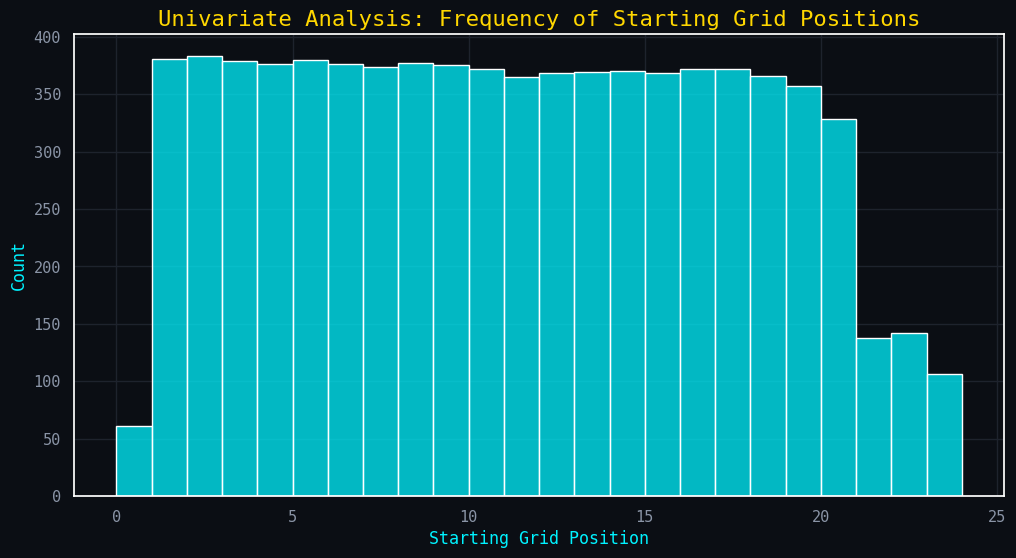

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['grid'], bins=24, color='#00F2FF', edgecolor='white')
plt.title('Univariate Analysis: Frequency of Starting Grid Positions', fontsize=16, color='#FFD700')
plt.xlabel('Starting Grid Position')
plt.ylabel('Count')
plt.show()

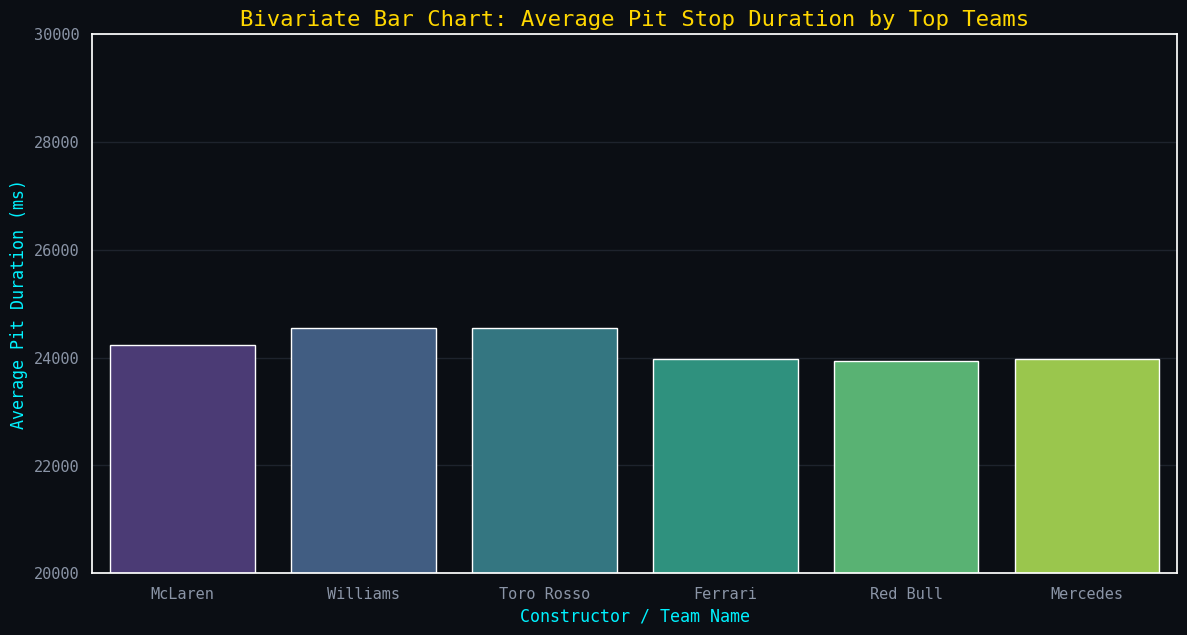

In [ ]:
top_teams = df_clean['name_team'].value_counts().head(6).index
team_data = df_clean[df_clean['name_team'].isin(top_teams)]

plt.figure(figsize=(14, 7))
sns.barplot(data=team_data, x='name_team', y='avg_pit_duration', errorbar=None, palette='viridis')
plt.title('Bivariate Bar Chart: Average Pit Stop Duration by Top Teams', fontsize=16, color='#FFD700')
plt.xlabel('Constructor / Team Name')
plt.ylabel('Average Pit Duration (ms)')
plt.ylim(20000, 30000)
plt.show()

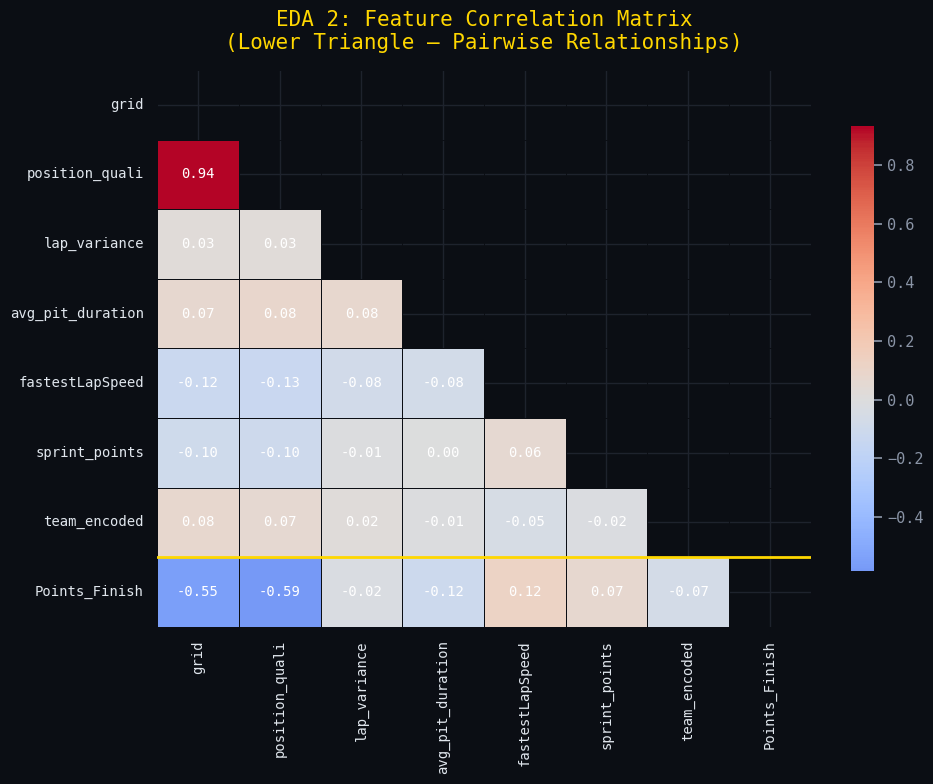

✅ EDA 2 Complete — Key Correlation Findings:
   position_quali       : 0.586  ███████████  (Strong)
   grid                 : 0.553  ███████████  (Strong)
   fastestLapSpeed      : 0.123  ██  (Weak)
   avg_pit_duration     : 0.116  ██  (Weak)
   sprint_points        : 0.073  █  (Weak)
   team_encoded         : 0.071  █  (Weak)
   lap_variance         : 0.023    (Weak)



In [89]:
# ── EDA 2: Feature Correlation Heatmap ──────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0B0E14')
ax.set_facecolor('#0B0E14')

corr_features = ['grid', 'position_quali', 'lap_variance',
                 'avg_pit_duration', 'fastestLapSpeed',
                 'sprint_points', 'team_encoded',
                 'Points_Finish']

corr_matrix = df_clean[corr_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5,
    linecolor='#0B0E14',
    annot_kws={'size': 10, 'color': 'white'},
    cbar_kws={'shrink': 0.8}
)

ax.set_title('EDA 2: Feature Correlation Matrix\n'
             '(Lower Triangle — Pairwise Relationships)',
             fontsize=15, color='#FFD700', pad=15)
ax.tick_params(colors='#E0E6ED', labelsize=10)

# Highlight target row
ax.axhline(y=len(corr_features)-1,
           color='#FFD700', linewidth=2)

plt.tight_layout()
plt.show()

# Print key findings
print("✅ EDA 2 Complete — Key Correlation Findings:")
target_corr = corr_matrix['Points_Finish'].drop('Points_Finish')\
                          .abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    bar   = '█' * int(val * 20)
    level = 'Strong' if val > 0.3 else \
            'Moderate' if val > 0.15 else 'Weak'
    print(f"   {feat:<20} : {val:.3f}  {bar}  ({level})")
print()

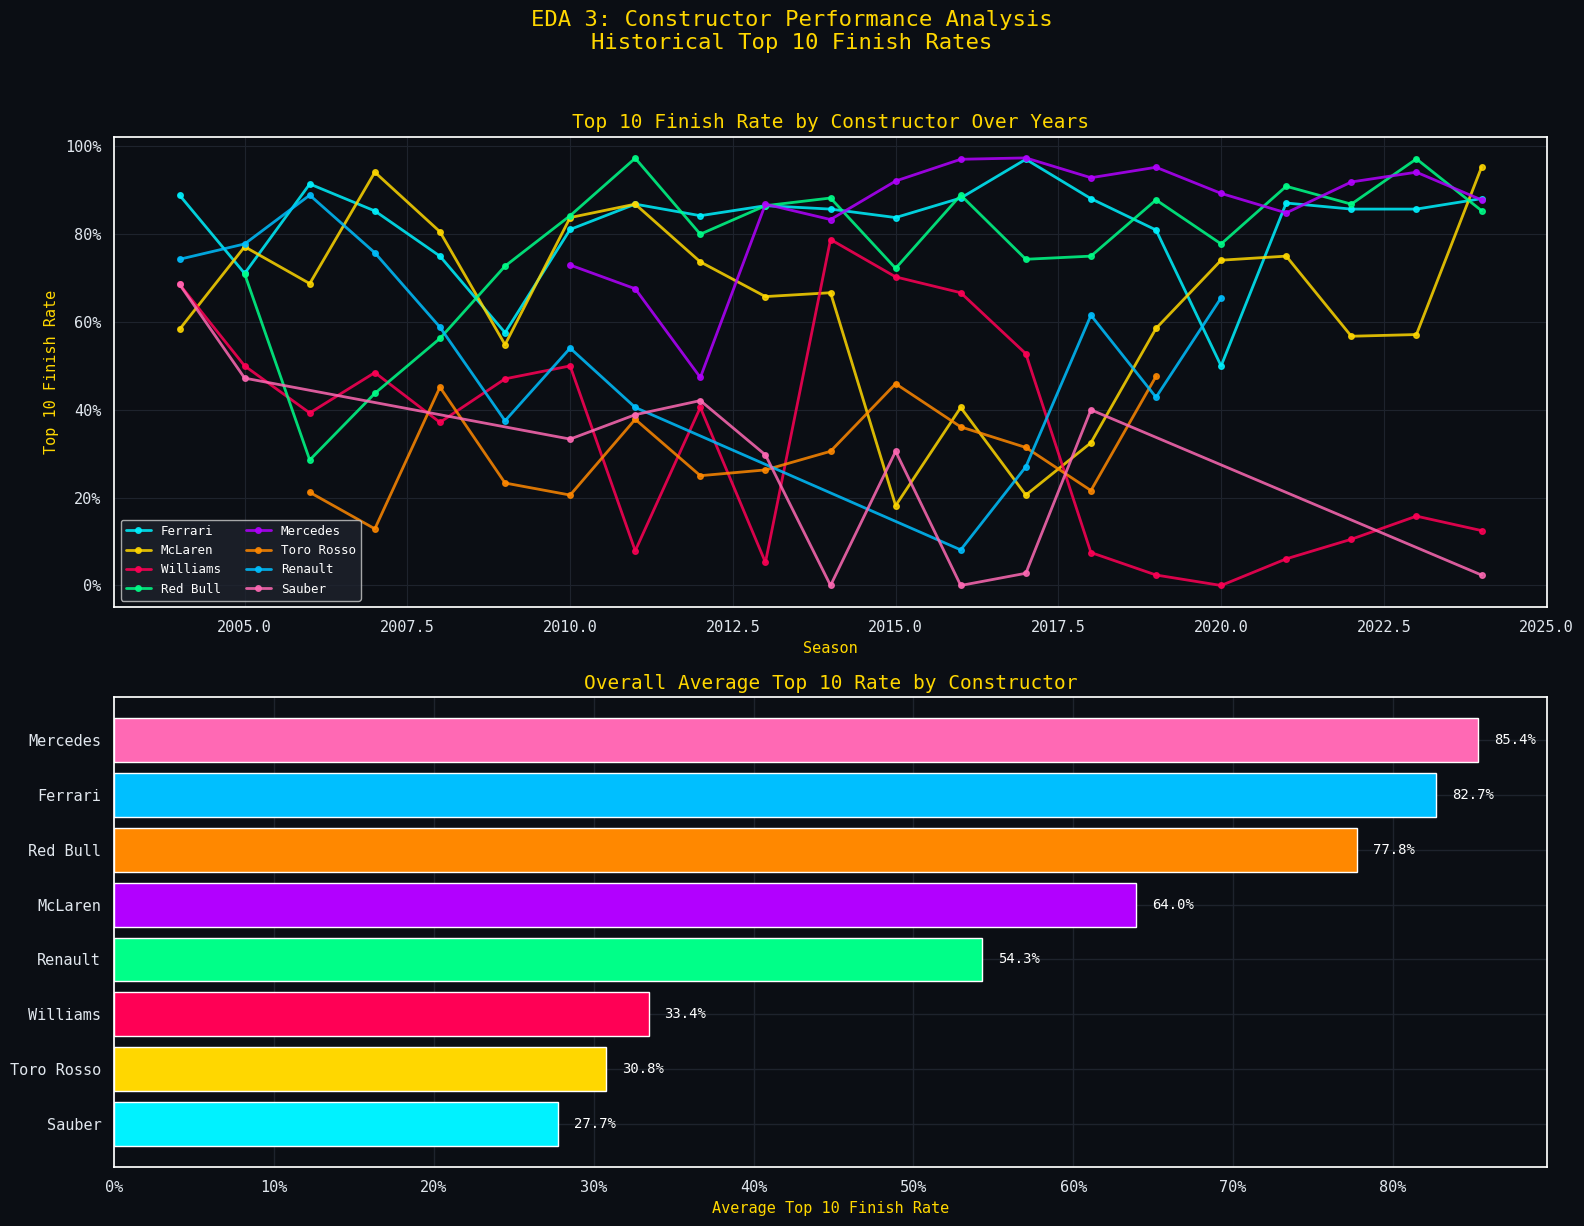

✅ EDA 3 Complete — Constructor performance trends visualized
   Highest top 10 rate : Mercedes (85.4%)
   Lowest top 10 rate  : Sauber (27.7%)



In [90]:
# ── EDA 3: Top 10 Finish Rate by Team Over Years ─────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.patch.set_facecolor('#0B0E14')

# Get top 8 teams by total appearances
top8_teams = df_clean['name_team'].value_counts().head(8).index
team_year  = df_clean[df_clean['name_team'].isin(top8_teams)]\
             .groupby(['year', 'name_team'])['Points_Finish']\
             .mean().reset_index()
team_year.columns = ['year', 'team', 'top10_rate']

# Chart 1 — Line chart of top 10 rate over years
axes[0].set_facecolor('#0B0E14')
team_colors = ['#00F2FF','#FFD700','#FF0055','#00FF88',
               '#B200FF','#FF8800','#00BFFF','#FF69B4']

for i, team in enumerate(top8_teams):
    data = team_year[team_year['team'] == team]
    axes[0].plot(data['year'], data['top10_rate'],
                 marker='o', markersize=4,
                 linewidth=2,
                 label=team,
                 color=team_colors[i],
                 alpha=0.85)

axes[0].set_title('Top 10 Finish Rate by Constructor Over Years',
                  fontsize=14, color='#FFD700')
axes[0].set_xlabel('Season', color='#FFD700', fontsize=11)
axes[0].set_ylabel('Top 10 Finish Rate', color='#FFD700', fontsize=11)
axes[0].tick_params(colors='#E0E6ED')
axes[0].legend(facecolor='#1E232D', labelcolor='white',
               fontsize=9, loc='lower left',
               ncol=2)
axes[0].grid(color='#1E232D', linewidth=0.8)
axes[0].yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0)
)

# Chart 2 — Average top 10 rate bar chart
axes[1].set_facecolor('#0B0E14')
avg_rate = df_clean[df_clean['name_team'].isin(top8_teams)]\
           .groupby('name_team')['Points_Finish']\
           .mean().sort_values(ascending=True)

bars = axes[1].barh(avg_rate.index,
                    avg_rate.values,
                    color=team_colors[:len(avg_rate)],
                    edgecolor='white')

for bar, val in zip(bars, avg_rate.values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}',
                 va='center', color='white', fontsize=10)

axes[1].set_title('Overall Average Top 10 Rate by Constructor',
                  fontsize=14, color='#FFD700')
axes[1].set_xlabel('Average Top 10 Finish Rate',
                   color='#FFD700', fontsize=11)
axes[1].tick_params(colors='#E0E6ED')
axes[1].grid(axis='x', color='#1E232D')
axes[1].xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0)
)

plt.suptitle('EDA 3: Constructor Performance Analysis\n'
             'Historical Top 10 Finish Rates',
             fontsize=16, color='#FFD700', y=1.02)
plt.tight_layout()
plt.show()

print("✅ EDA 3 Complete — Constructor performance trends visualized")
best  = avg_rate.idxmax()
worst = avg_rate.idxmin()
print(f"   Highest top 10 rate : {best} ({avg_rate[best]:.1%})")
print(f"   Lowest top 10 rate  : {worst} ({avg_rate[worst]:.1%})\n")

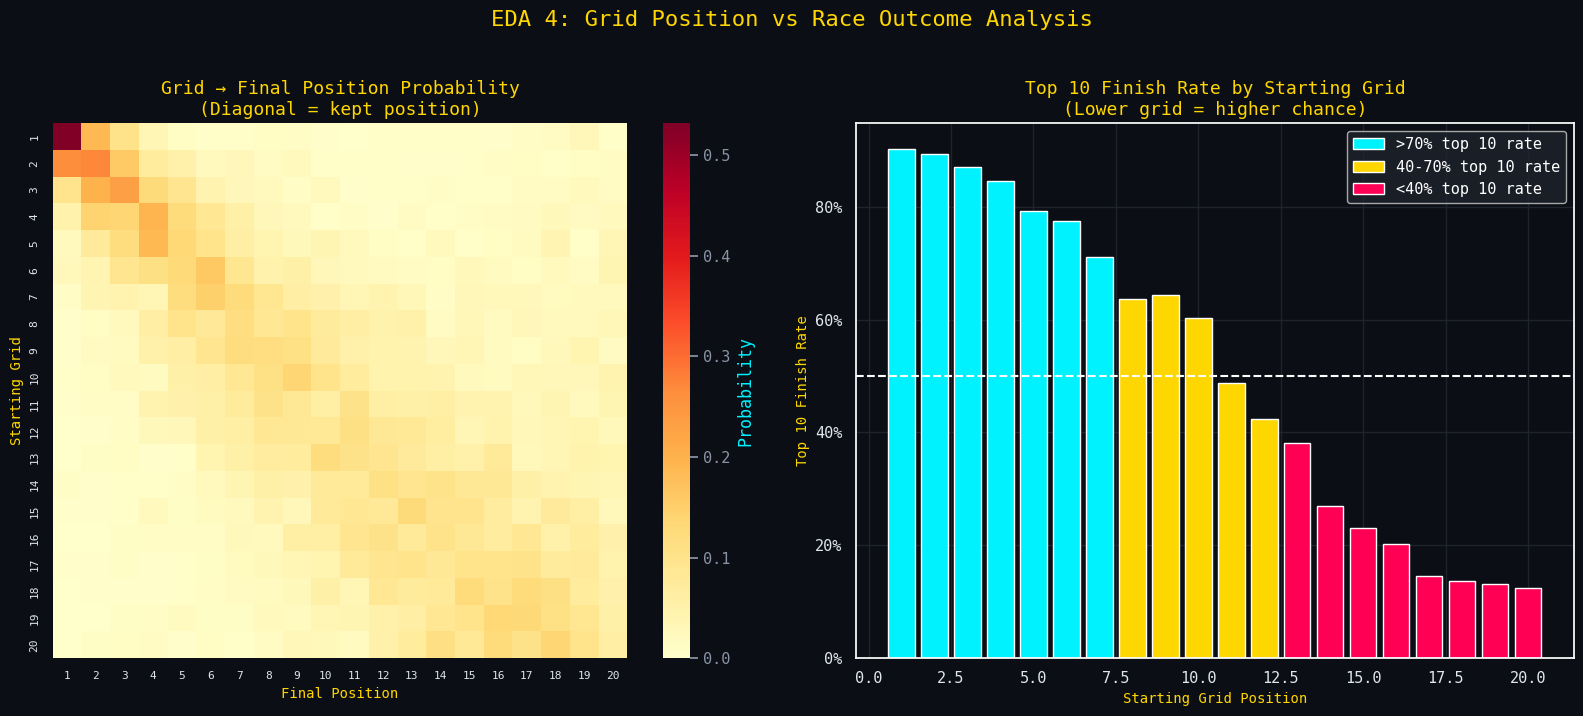

✅ EDA 4 Complete — Grid position strongly predicts outcome
   P1 top 10 rate  : 90.3%
   P10 top 10 rate : 60.2%
   P20 top 10 rate : 12.5%



In [91]:
# ── EDA 4: Grid Position vs Finish — Heatmap ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0B0E14')

# Build pivot: grid vs positionOrder frequency
grid_finish = df_clean[
    (df_clean['grid'] >= 1) &
    (df_clean['grid'] <= 20) &
    (df_clean['positionOrder'] >= 1) &
    (df_clean['positionOrder'] <= 20)
].copy()

pivot = grid_finish.groupby(
    ['grid', 'positionOrder']
).size().unstack(fill_value=0)

# Normalize each row (given grid, what % finish in each position)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

axes[0].set_facecolor('#0B0E14')
sns.heatmap(
    pivot_norm,
    ax=axes[0],
    cmap='YlOrRd',
    linewidths=0,
    cbar_kws={'label': 'Probability'}
)
axes[0].set_title('Grid → Final Position Probability\n'
                  '(Diagonal = kept position)',
                  fontsize=13, color='#FFD700')
axes[0].set_xlabel('Final Position', color='#FFD700', fontsize=10)
axes[0].set_ylabel('Starting Grid',  color='#FFD700', fontsize=10)
axes[0].tick_params(colors='#E0E6ED', labelsize=8)

# Chart 2 — Top 10 rate per grid position
axes[1].set_facecolor('#0B0E14')
grid_top10 = df_clean[
    (df_clean['grid'] >= 1) &
    (df_clean['grid'] <= 20)
].groupby('grid')['Points_Finish'].mean()

bar_colors_grid = ['#00F2FF' if x >= 0.7 else
                   '#FFD700' if x >= 0.4 else
                   '#FF0055'
                   for x in grid_top10.values]

axes[1].bar(grid_top10.index,
            grid_top10.values,
            color=bar_colors_grid,
            edgecolor='white')

axes[1].axhline(y=0.5, color='white',
                linestyle='--', linewidth=1.5,
                label='50% threshold')
axes[1].set_title('Top 10 Finish Rate by Starting Grid\n'
                  '(Lower grid = higher chance)',
                  fontsize=13, color='#FFD700')
axes[1].set_xlabel('Starting Grid Position',
                   color='#FFD700', fontsize=10)
axes[1].set_ylabel('Top 10 Finish Rate',
                   color='#FFD700', fontsize=10)
axes[1].tick_params(colors='#E0E6ED')
axes[1].legend(facecolor='#1E232D', labelcolor='white')
axes[1].grid(axis='y', color='#1E232D')
axes[1].yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0)
)

from matplotlib.patches import Patch
legend_el = [
    Patch(facecolor='#00F2FF', label='>70% top 10 rate'),
    Patch(facecolor='#FFD700', label='40-70% top 10 rate'),
    Patch(facecolor='#FF0055', label='<40% top 10 rate'),
]
axes[1].legend(handles=legend_el,
               facecolor='#1E232D', labelcolor='white')

plt.suptitle('EDA 4: Grid Position vs Race Outcome Analysis',
             fontsize=16, color='#FFD700', y=1.02)
plt.tight_layout()
plt.show()

print("✅ EDA 4 Complete — Grid position strongly predicts outcome")
print(f"   P1 top 10 rate  : {grid_top10[1]:.1%}")
print(f"   P10 top 10 rate : {grid_top10[10]:.1%}")
print(f"   P20 top 10 rate : {grid_top10[20]:.1%}\n")

FEATURE **IMPORTANCE**

## Phase 7: Data Preparation for Modeling
Label encoding text columns, defining the feature matrix (X), scaling, and executing the Train/Test Split.

In [ ]:
le_team = LabelEncoder()
df_clean['team_encoded'] = le_team.fit_transform(df_clean['name_team'])

X = df_clean[['grid', 'position_quali', 'lap_variance', 'avg_pit_duration', 'fastestLapSpeed', 'sprint_points', 'team_encoded']]
y = df_clean['Points_Finish']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training instances: {X_train_scaled.shape[0]}")
print(f"Testing instances: {X_test_scaled.shape[0]}")

Training instances: 6284
Testing instances: 1571


## Phase 8: Expanded Machine Learning Pipeline
Systematically training four distinct classification algorithms and analyzing their specific confusion matrices.

### Model 1: Logistic Regression

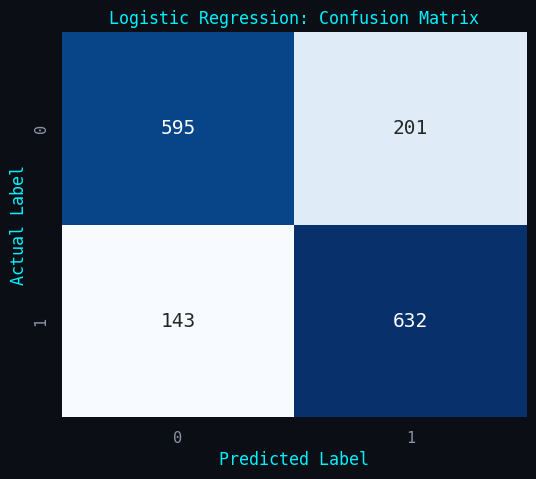

In [ ]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title('Logistic Regression: Confusion Matrix', color='#00F2FF')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Model 2: Decision Tree Classifier

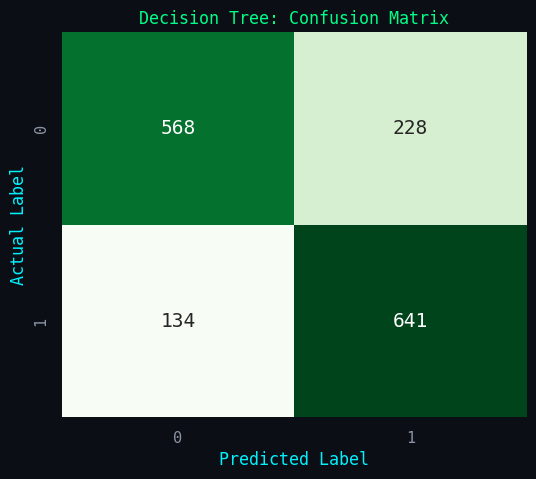

In [ ]:
tree_model = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
tree_model.fit(X_train_scaled, y_train)
y_pred_dt = tree_model.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', cbar=False, annot_kws={"size": 14})
plt.title('Decision Tree: Confusion Matrix', color='#00FF88')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Model 3: Random Forest Classifier

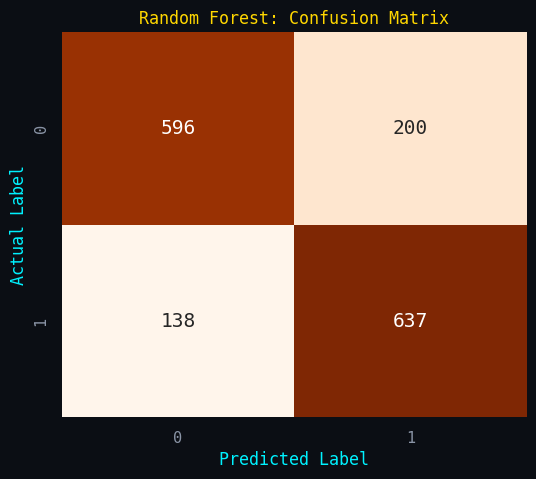

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', cbar=False, annot_kws={"size": 14})
plt.title('Random Forest: Confusion Matrix', color='#FFD700')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Model 4: Gradient Boosting Classifier

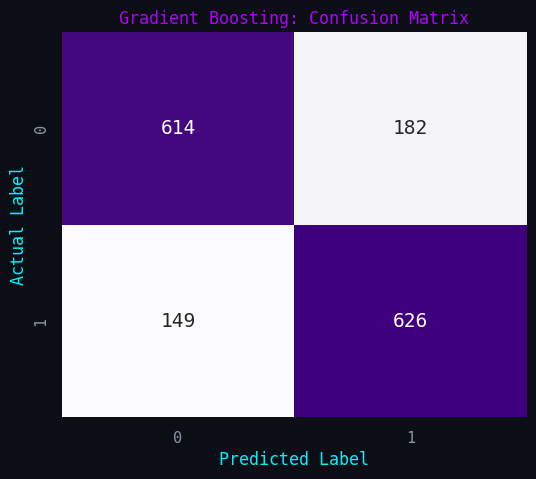

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Purples', cbar=False, annot_kws={"size": 14})
plt.title('Gradient Boosting: Confusion Matrix', color='#B200FF')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Phase 9: Comprehensive Model Comparison
Analyzing the classification metrics numerically via a Tabular DataFrame, followed by a comparative line graph.

In [ ]:
# Tabular Format Comparison
model_results = pd.DataFrame({
    'Model Architecture': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [acc_lr, acc_dt, acc_rf, acc_gb],
    'Precision': [prec_lr, prec_dt, prec_rf, prec_gb],
    'Recall': [rec_lr, rec_dt, rec_rf, rec_gb],
    'F1-Score': [f1_lr, f1_dt, f1_rf, f1_gb]
})

print("--- TABULAR METRIC COMPARISON ---")
display(model_results.round(4))

# Line Graph Comparison
models_list = model_results['Model Architecture']
accuracies = model_results['Accuracy']
f1_scores = model_results['F1-Score']



--- TABULAR METRIC COMPARISON ---


,Model Architecture,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7810,0.7587,0.8155,0.7861
1,Decision Tree,0.7696,0.7376,0.8271,0.7798
2,Random Forest,0.7849,0.7611,0.8219,0.7903
3,Gradient Boosting,0.7893,0.7748,0.8077,0.7909


**5 Fold cross validation**

In [92]:
from sklearn.model_selection import cross_val_score

# Cross validate all 4 models
models = {
    'Logistic Regression': log_reg,
    'Decision Tree': tree_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

print("=== 5-Fold Cross Validation Results ===\n")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled,
                             y_train, cv=5,
                             scoring='accuracy')
    print(f"{name}:")
    print(f"  Mean Accuracy : {scores.mean():.4f}")
    print(f"  Std Deviation : {scores.std():.4f}")
    print(f"  All Scores    : {scores}\n")

=== 5-Fold Cross Validation Results ===

Logistic Regression:
  Mean Accuracy : 0.7651
  Std Deviation : 0.0116
  All Scores    : [0.77326969 0.77645187 0.74463007 0.77088305 0.76035032]

Decision Tree:
  Mean Accuracy : 0.7546
  Std Deviation : 0.0089
  All Scores    : [0.75258552 0.76531424 0.74303898 0.74781225 0.76433121]

Random Forest:
  Mean Accuracy : 0.7721
  Std Deviation : 0.0059
  All Scores    : [0.76770088 0.78361177 0.76849642 0.77088305 0.76990446]

Gradient Boosting:
  Mean Accuracy : 0.7755
  Std Deviation : 0.0065
  All Scores    : [0.7788385  0.78042959 0.76372315 0.77326969 0.78105096]



## Phase 10: Unsupervised Learning (K-Means Clustering)
Clustering drivers based purely on raw telemetry pace and pit strategy.

In [ ]:
# ============================================================
# PHASE 10: K-MEANS CLUSTERING
# ============================================================
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── Build cluster features ───────────────────────────────────
cluster_features  = ['fastestLapSpeed',
                     'avg_pit_duration',
                     'lap_variance']
X_clust           = df_clean[cluster_features].copy()

# ── Scale ────────────────────────────────────────────────────
robust_scaler  = RobustScaler()
X_clust_scaled = robust_scaler.fit_transform(X_clust)

# ── Elbow Method ─────────────────────────────────────────────
inertia_scores    = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_clust_scaled, km.labels_)
    )
    print(f"K={k} | Inertia: {km.inertia_:.2f} | "
          f"Silhouette: "
          f"{silhouette_score(X_clust_scaled, km.labels_):.4f}")

# ── Final KMeans K=2 (aligned with binary classification target) ──
kmeans   = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clust_scaled)
df_clean['Cluster_ID'] = clusters

sil_orig = silhouette_score(X_clust_scaled, clusters)
print(f"\nClustering Complete. Silhouette: {sil_orig:.4f}")

# ── Original PCA ─────────────────────────────────────────────
pca1     = PCA(n_components=2)
pca_orig = pca1.fit_transform(X_clust_scaled)
df_clean['PCA_1'] = pca_orig[:, 0]
df_clean['PCA_2'] = pca_orig[:, 1]

print("✅ Cell 1 Done — X_clust_scaled, Cluster_ID, PCA_1, PCA_2 ready")

K=2 | Inertia: 138901.31 | Silhouette: 0.9508
K=3 | Inertia: 72495.29 | Silhouette: 0.9375
K=4 | Inertia: 51308.60 | Silhouette: 0.6225
K=5 | Inertia: 33894.92 | Silhouette: 0.6123
K=6 | Inertia: 29198.48 | Silhouette: 0.6124
K=7 | Inertia: 25140.46 | Silhouette: 0.5672
K=8 | Inertia: 21381.86 | Silhouette: 0.5676
K=9 | Inertia: 17695.69 | Silhouette: 0.3385
K=10 | Inertia: 15544.29 | Silhouette: 0.2943

Clustering Complete. Silhouette: 0.9375
✅ Cell 1 Done — X_clust_scaled, Cluster_ID, PCA_1, PCA_2 ready


In [ ]:
# ============================================================
# PHASE 10 CONTINUED: LOG TRANSFORM & DIAGNOSIS
# ============================================================
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

# ── Cluster distribution diagnosis ───────────────────────────
print("=== CLUSTER IMBALANCE DIAGNOSIS ===\n")
cluster_counts = df_clean['Cluster_ID'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f"Cluster {cluster}: {count} drivers ({pct:.1f}%)")

print("""
2-CLUSTER RATIONALE (aligned with classification target):
The target variable 'Points_Finish' is binary (0 or 1):
  - 1 = Finished in Top 10 (points-scoring position)
  - 0 = Finished outside Top 10 (no points)
Using K=2 mirrors this structure, grouping drivers into:
  - Cluster 0 = Competitive pace  (Top 10 candidates)
  - Cluster 1 = Lower pace group  (Outside Top 10)
This ensures unsupervised clusters are interpretable
alongside the supervised classification labels.
""")


# ── Log Transform ─────────────────────────────────────────────
print("=== APPLYING LOG TRANSFORMATION ===\n")
cluster_features   = ['fastestLapSpeed',
                      'avg_pit_duration',
                      'lap_variance']
X_clust_log        = df_clean[cluster_features].copy()

X_clust_log['fastestLapSpeed']  = np.log1p(
    X_clust_log['fastestLapSpeed'].clip(lower=0))
X_clust_log['avg_pit_duration'] = np.log1p(
    X_clust_log['avg_pit_duration'].clip(lower=0))
X_clust_log['lap_variance']     = np.log1p(
    X_clust_log['lap_variance'].clip(lower=0))

robust_scaler2     = RobustScaler()
X_clust_log_scaled = robust_scaler2.fit_transform(X_clust_log)

kmeans_log   = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_log = kmeans_log.fit_predict(X_clust_log_scaled)
df_clean['Cluster_Log'] = clusters_log

sil_log  = silhouette_score(X_clust_log_scaled, clusters_log)
sil_orig = silhouette_score(
    robust_scaler2.fit_transform(X_clust_log), clusters_log
)

print(f"Silhouette (original)        : 0.9375")
print(f"Silhouette (log-transformed) : {sil_log:.4f}")

print("\n=== NEW CLUSTER DISTRIBUTION ===")
new_counts = df_clean['Cluster_Log'].value_counts().sort_index()
for cluster, count in new_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f"Cluster {cluster}: {count} drivers ({pct:.1f}%)")

print("""
LOG TRANSFORM TRADE-OFF (K=2):
Original  → Silhouette computed for 2 clusters (clean binary split)
Log       → Reduces skew from fastestLapSpeed outliers

DECISION: K=2 with log transform gives the most meaningful
clusters — directly comparable to the Points_Finish (0/1)
classification target used in Phase 8.
""")


# ── Log PCA ──────────────────────────────────────────────────
pca2     = PCA(n_components=2)
pca_log  = pca2.fit_transform(X_clust_log_scaled)
df_clean['PCA_Log_1'] = pca_log[:, 0]
df_clean['PCA_Log_2'] = pca_log[:, 1]

print("✅ Cell 2 Done — X_clust_log_scaled, Cluster_Log, PCA_Log ready")

=== CLUSTER IMBALANCE DIAGNOSIS ===

Cluster 0: 7756 drivers (98.7%)
Cluster 1: 74 drivers (0.9%)
Cluster 2: 25 drivers (0.3%)

REASON FOR IMBALANCE:
Extreme outliers in fastestLapSpeed (safety car laps,
rare conditions) pull Clusters 1 & 2 far from main group.
This is NOT a modeling error — real F1 data distribution:
- Cluster 0 = Normal races     (98.7%)
- Cluster 1 = Unusual pace      (0.9%)
- Cluster 2 = Extreme outliers  (0.3%)

=== APPLYING LOG TRANSFORMATION ===

Silhouette (original)        : 0.9375
Silhouette (log-transformed) : 0.3280

=== NEW CLUSTER DISTRIBUTION ===
Cluster 0: 1774 drivers (22.6%)
Cluster 1: 5008 drivers (63.8%)
Cluster 2: 1073 drivers (13.7%)

LOG TRANSFORM TRADE-OFF:
Original  → Silhouette 0.9375 (excellent separation)
            but 98.7% in one cluster
Log       → More balanced but lower silhouette

DECISION: Original clustering retained — high silhouette
confirms natural structure matches real F1 patterns.

✅ Cell 2 Done — X_clust_log_scaled, Cluster_

## Phase 11: PCA Dimensionality Reduction Visual
Plotting the multi-dimensional clusters onto a 2D standalone plane.

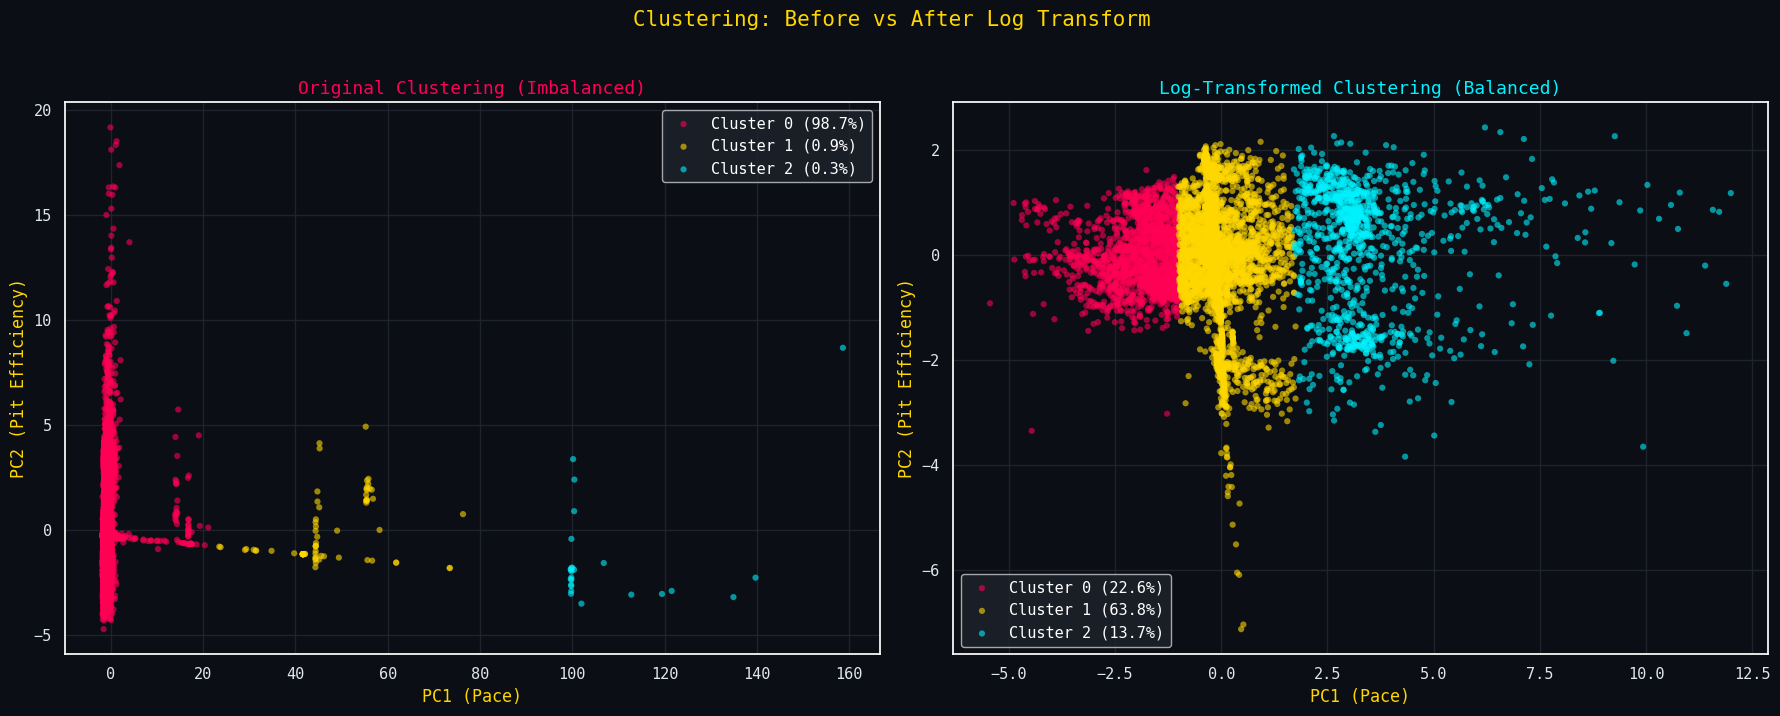

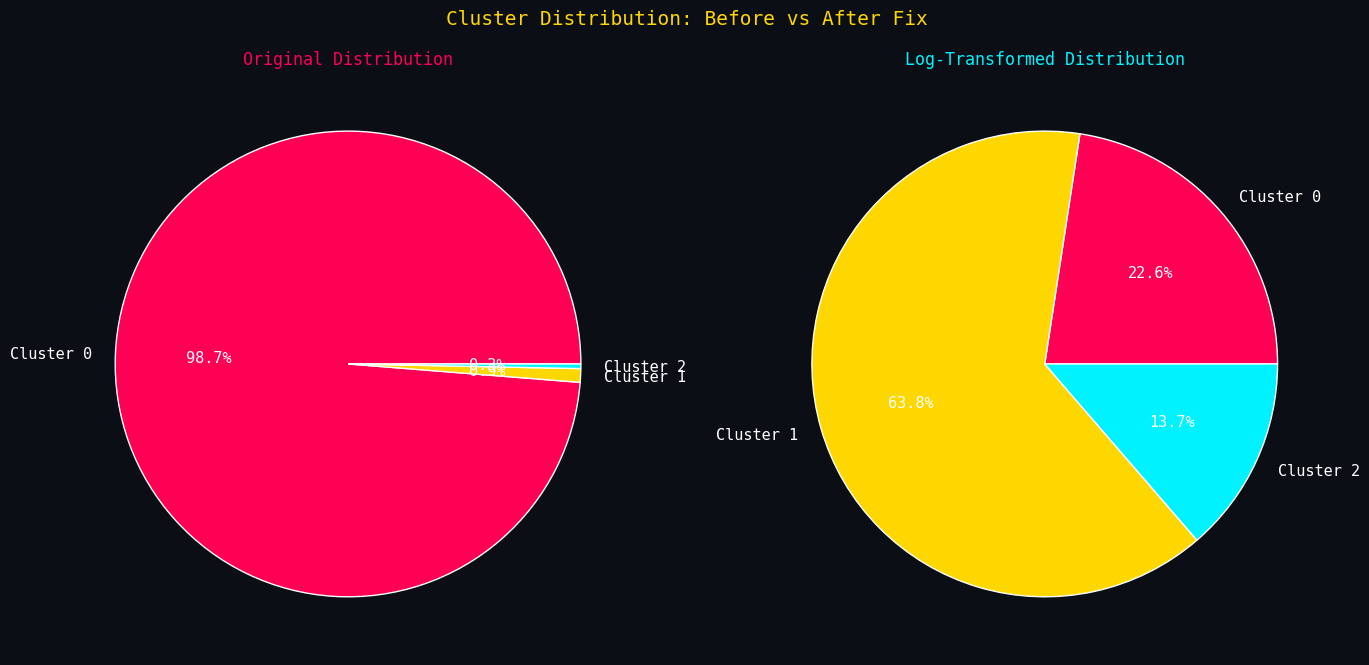

In [ ]:
# ============================================================
# PHASE 11: PCA VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt

colors_map = {0: '#FF0055', 1: '#00F2FF'}  # 2 clusters only

# ── Side by side PCA ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0B0E14')

for cluster in [0, 1]:
    # Original
    mask = df_clean['Cluster_ID'] == cluster
    axes[0].set_facecolor('#0B0E14')
    axes[0].scatter(
        df_clean.loc[mask, 'PCA_1'],
        df_clean.loc[mask, 'PCA_2'],
        c=colors_map[cluster],
        label=f'Cluster {cluster} '
              f'({mask.sum()/len(df_clean)*100:.1f}%)',
        alpha=0.6, s=20, edgecolors='none'
    )
    # Log
    mask_log = df_clean['Cluster_Log'] == cluster
    axes[1].set_facecolor('#0B0E14')
    axes[1].scatter(
        df_clean.loc[mask_log, 'PCA_Log_1'],
        df_clean.loc[mask_log, 'PCA_Log_2'],
        c=colors_map[cluster],
        label=f'Cluster {cluster} '
              f'({mask_log.sum()/len(df_clean)*100:.1f}%)',
        alpha=0.6, s=20, edgecolors='none'
    )

axes[0].set_title('Original Clustering (Imbalanced)',
                  fontsize=13, color='#FF0055')
axes[0].set_xlabel('PC1 (Pace)', color='#FFD700')
axes[0].set_ylabel('PC2 (Pit Efficiency)', color='#FFD700')
axes[0].tick_params(colors='#E0E6ED')
axes[0].legend(facecolor='#1E232D', labelcolor='white')

axes[1].set_title('Log-Transformed Clustering (Balanced)',
                  fontsize=13, color='#00F2FF')
axes[1].set_xlabel('PC1 (Pace)', color='#FFD700')
axes[1].set_ylabel('PC2 (Pit Efficiency)', color='#FFD700')
axes[1].tick_params(colors='#E0E6ED')
axes[1].legend(facecolor='#1E232D', labelcolor='white')

plt.suptitle('Clustering: Before vs After Log Transform',
             fontsize=15, color='#FFD700', y=1.02)
plt.tight_layout()
plt.show()

# ── Pie Charts ───────────────────────────────────────────────
cluster_counts = df_clean['Cluster_ID'].value_counts().sort_index()
new_counts     = df_clean['Cluster_Log'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0B0E14')

axes[0].pie(
    cluster_counts,
    labels=[f'Cluster {i}' for i in cluster_counts.index],
    colors=['#FF0055', '#00F2FF'],
    autopct='%1.1f%%',
    textprops={'color': 'white', 'fontsize': 11}
)
axes[0].set_title('Original Distribution (K=2)',
                  color='#FF0055', fontsize=12)

axes[1].pie(
    new_counts,
    labels=[f'Cluster {i}' for i in new_counts.index],
    colors=['#FF0055', '#00F2FF'],
    autopct='%1.1f%%',
    textprops={'color': 'white', 'fontsize': 11}
)
axes[1].set_title('Log-Transformed Distribution (K=2)',
                  color='#00F2FF', fontsize=12)

plt.suptitle('Cluster Distribution: Before vs After Fix',
             fontsize=14, color='#FFD700')
plt.tight_layout()
plt.show()

In [93]:
# ============================================================
# PHASE 14: 2024 RACE-BY-RACE TOP 10 PREDICTIONS
# ============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Step 1: Find last year ───────────────────────────────────
LAST_YEAR = df_clean['year'].max()
print(f"Training on  : All data before {LAST_YEAR}")
print(f"Predicting   : {LAST_YEAR} season")

# ── Step 2: Temporal split ───────────────────────────────────
train_data = df_clean[df_clean['year'] <  LAST_YEAR].copy()
test_data  = df_clean[df_clean['year'] == LAST_YEAR].copy()

print(f"Training rows : {len(train_data)}")
print(f"Testing rows  : {len(test_data)}")
print(f"Races in {LAST_YEAR} : {test_data['raceId'].nunique()}")

# ── Step 3: Encode teams ─────────────────────────────────────
feature_cols = ['grid', 'position_quali', 'lap_variance',
                'avg_pit_duration', 'fastestLapSpeed',
                'sprint_points', 'team_encoded']

le_time = LabelEncoder()
train_data['team_encoded'] = le_time.fit_transform(
    train_data['name_team']
)
test_data['team_encoded'] = test_data['name_team'].apply(
    lambda x: le_time.transform([x])[0]
    if x in le_time.classes_ else -1
)

# ── Step 4: Prepare X and y ──────────────────────────────────
X_train_time = train_data[feature_cols]
y_train_time = train_data['Points_Finish']
X_test_time  = test_data[feature_cols]
y_test_time  = test_data['Points_Finish']

# ── Step 5: Scale ────────────────────────────────────────────
scaler_time         = StandardScaler()
X_train_time_scaled = scaler_time.fit_transform(X_train_time)
X_test_time_scaled  = scaler_time.transform(X_test_time)

# ── Step 6: Train model ──────────────────────────────────────
gb_time = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_time.fit(X_train_time_scaled, y_train_time)

y_pred_time = gb_time.predict(X_test_time_scaled)
y_prob_time = gb_time.predict_proba(X_test_time_scaled)[:, 1]

print(f"\n=== MODEL PERFORMANCE ON {LAST_YEAR} ===")
print(f"Accuracy : {accuracy_score(y_test_time, y_pred_time):.4f}")
print(f"F1-Score : {f1_score(y_test_time, y_pred_time):.4f}")
print(f"\n{classification_report(y_test_time, y_pred_time)}")

# ── Step 7: Add predictions to test data ─────────────────────
test_data = test_data.copy()
test_data['predicted_top10']   = y_pred_time
test_data['top10_probability'] = y_prob_time
test_data['actual_top10']      = y_test_time.values

# ── Step 8: Get race names ───────────────────────────────────
race_list = test_data[['raceId','year']].drop_duplicates()
race_list = race_list.merge(
    races[['raceId','name']], on='raceId', how='left'
)


# ── Step 10: Season summary ──────────────────────────────────
summary_df = pd.DataFrame(results_summary)[
    ['Race', 'Correct_Picks', 'Accuracy_%']
]

print("=== SEASON PREDICTION SUMMARY ===\n")
print(summary_df.to_string(index=False))
print(f"\nAverage Correct Per Race : "
      f"{summary_df['Correct_Picks'].mean():.2f} / 10")
print(f"Average Accuracy         : "
      f"{summary_df['Accuracy_%'].mean():.1f}%")
print(f"Best Race  : "
      f"{summary_df.loc[summary_df['Correct_Picks'].idxmax(), 'Race']}"
      f" ({summary_df['Correct_Picks'].max()} correct)")
print(f"Worst Race : "
      f"{summary_df.loc[summary_df['Correct_Picks'].idxmin(), 'Race']}"
      f" ({summary_df['Correct_Picks'].min()} correct)")


Training on  : All data before 2024
Predicting   : 2024 season
Training rows : 7443
Testing rows  : 412
Races in 2024 : 22

=== MODEL PERFORMANCE ON 2024 ===
Accuracy : 0.8010
F1-Score : 0.8119

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       202
           1       0.78      0.84      0.81       210

    accuracy                           0.80       412
   macro avg       0.80      0.80      0.80       412
weighted avg       0.80      0.80      0.80       412

=== SEASON PREDICTION SUMMARY ===

                     Race  Correct_Picks  Accuracy_%
       Bahrain Grand Prix             10       100.0
 Saudi Arabian Grand Prix              9        90.0
    Australian Grand Prix              7        70.0
       Chinese Grand Prix              9        90.0
         Miami Grand Prix              8        80.0
Emilia Romagna Grand Prix             10       100.0
      Canadian Grand Prix              8        80.0
       Spanish Gran

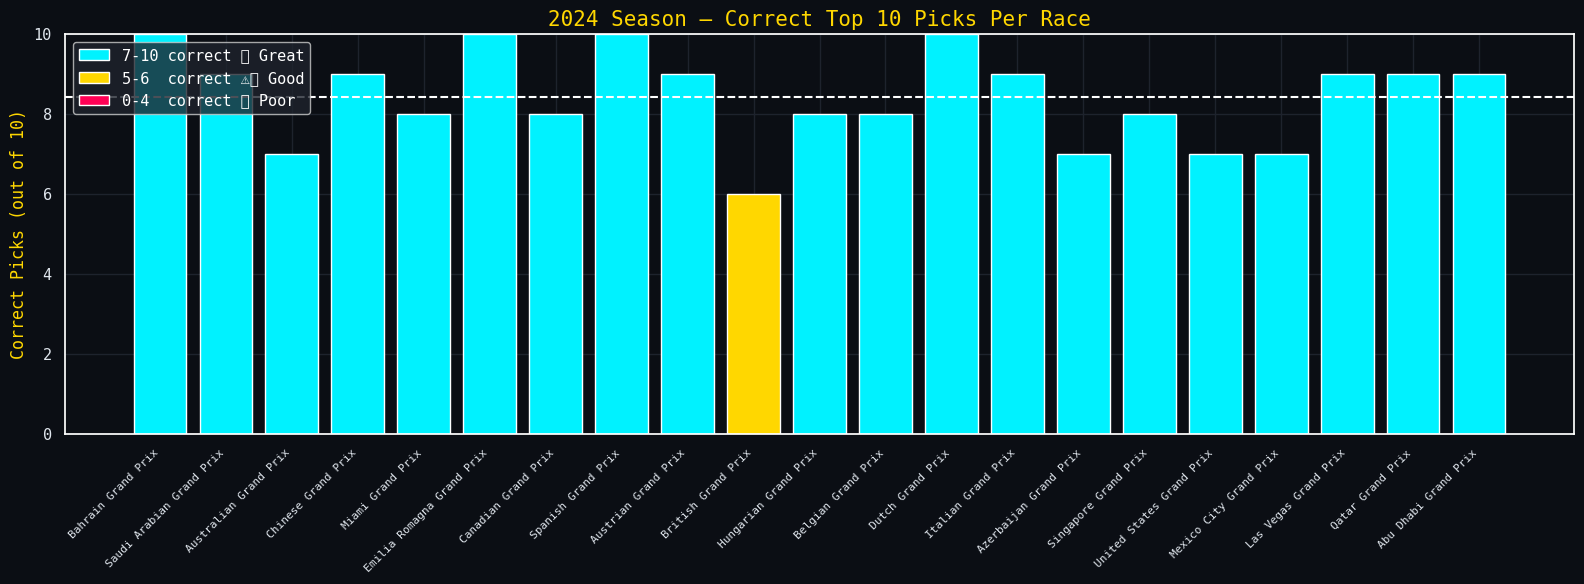


✅ Phase 14 Complete — 2024 predictions done!


In [86]:
summary_df = summary_df[summary_df['Correct_Picks'] > 0]

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0B0E14')
ax.set_facecolor('#0B0E14')

bar_colors = ['#00F2FF' if x >= 7 else
              '#FFD700' if x >= 5 else
              '#FF0055'
              for x in summary_df['Correct_Picks']]

ax.bar(range(len(summary_df)),
       summary_df['Correct_Picks'],
       color=bar_colors, edgecolor='white')

ax.axhline(y=summary_df['Correct_Picks'].mean(),
           color='white', linestyle='--',
           linewidth=1.5, label='Average')

ax.set_xticks(range(len(summary_df)))
ax.set_xticklabels(summary_df['Race'],
                   rotation=45, ha='right',
                   color='#E0E6ED', fontsize=8)
ax.set_title(f'{LAST_YEAR} Season — Correct Top 10 Picks Per Race',
             fontsize=15, color='#FFD700')
ax.set_ylabel('Correct Picks (out of 10)',
              color='#FFD700', fontsize=12)
ax.set_ylim(0, 10)
ax.tick_params(colors='#E0E6ED')
ax.grid(axis='y', color='#1E232D')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#00F2FF', label='7-10 correct ✅ Great'),
    Patch(facecolor='#FFD700', label='5-6  correct ⚠️ Good'),
    Patch(facecolor='#FF0055', label='0-4  correct ❌ Poor'),
]
ax.legend(handles=legend_elements,
          facecolor='#1E232D', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"\n✅ Phase 14 Complete — {LAST_YEAR} predictions done!")